# Exchange Netflows — do the coins tell you when to sell? 🪙
### "Coins pouring onto exchanges = holders about to dump." In plain English.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Would_the_engine_catch_it%3F: Yes](https://img.shields.io/badge/Would_the_engine_catch_it%3F-Yes-2ea44f?style=flat-square)

There's a story on-chain analysts love. Every crypto coin lives at an *address*, and you can watch coins move between them. When lots of Bitcoin **flows onto exchanges** (Binance, Coinbase…), the story goes, holders are moving coins somewhere they can *sell* — so a wave of deposits is **bearish**: a sell-off is coming. When coins flow *off* exchanges into private wallets, that's **bullish**: people are hodling.

It sounds airtight. So does BTC actually drop when 'net-inflows' turn positive?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from exchange_netflows import data, strategy as st

# SYNTHETIC-ONLY: a real BTC exchange-netflow tape is a paywalled address-clustering product,
# so there is NO real tape here (HAVE_REAL is always False, by design). Every computed cell runs
# the deterministic synthetic world, seed 584 — offline and reproducible.
HAVE_REAL = False
NULL, _ = data.synthetic_series(bear_beta=0.0, seed=584)        # the honest null world
print("synthetic null world:", len(NULL), "days | series fp", data.fingerprint(NULL),
      "| HAVE_REAL", HAVE_REAL)


synthetic null world: 1500 days | series fp 8c7301772d7b | HAVE_REAL False


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we even test this for free? | **No — and that's the headline.** The 'netflow' number is a *paid product*: someone has to figure out which of millions of addresses belong to exchanges, and that labelling is exactly what Glassnode / CryptoQuant / Nansen *sell*. The raw blockchain gives you transfers, not the exchange labels. |
| So what do we do instead? | Build a **fair simulated world** where we *know* the truth, and check two things: (a) if netflows really told you nothing, does our test correctly find nothing? (b) if we *plant* the effect, does the test catch it? |
| Does the test find a fake signal in the null world? | **No.** Slope of tomorrow's BTC return on today's netflow ≈ **0** (*t* 0.47), a coin-flip shuffle test gives *p* = 0.72. Nothing there — as it should be. |
| Could you trade it? | **No.** You can't buy the data, and even the simulated sign-timing book *loses* money after fees. |

> The folklore might be true. But on a no-key retail stack there is **nothing real to test it on** — and a fair simulation of 'netflows tell you nothing' shows an honest test finding exactly nothing.

## 1 · The claim

> *"When BTC net-inflows to exchanges rise, a sell-off is coming; when coins flow off to cold storage, it's bullish."* — the on-chain netflow folklore (CryptoQuant, Glassnode, Nansen).

**Netflow = deposits − withdrawals.** Positive netflow means, on net, coins are moving *to* exchanges. The intuition: you only send coins to an exchange when you want to sell them (or trade), so a spike in deposits is supply about to hit the market.

## 2 · So what?

If it worked, it would be a genuine *lead* indicator — you'd see the sellers coming before the price moved, and could step aside (or short) ahead of the drop. That's the dream of on-chain analysis: the blockchain is public, so *surely* it leaks intent.

The desk has tested the crypto claims a free stack **can** reach — [133 Crypto-Seasonality](../../133-crypto-seasonality/), [210 Crypto-Trend](../../210-crypto-trend/), [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/). This one is different: the data itself is behind a paywall.

## 3 · How would we even know?

1. **Get a netflow series.** …except you can't, for free. Labelling exchange addresses is the product these companies *sell*. So we build a **simulated** netflow + BTC world where we control the truth.
2. **Line up the timing.** Today's netflow (known at today's close) vs the BTC return over the *next* day. No peeking at the future.
3. **Two checks.** (a) In a *null* world where netflow means nothing, does our test correctly find nothing? (b) In a *planted* world where inflows really are bearish, does it catch it?

*Timing:* the signal is the netflow at today's close; we trade tomorrow's return. One day of lag, documented.

## 4 · The teardown — let's actually look

**In the fair NULL world (netflow tells you nothing), do 'high-inflow' days really see worse next-day returns?**

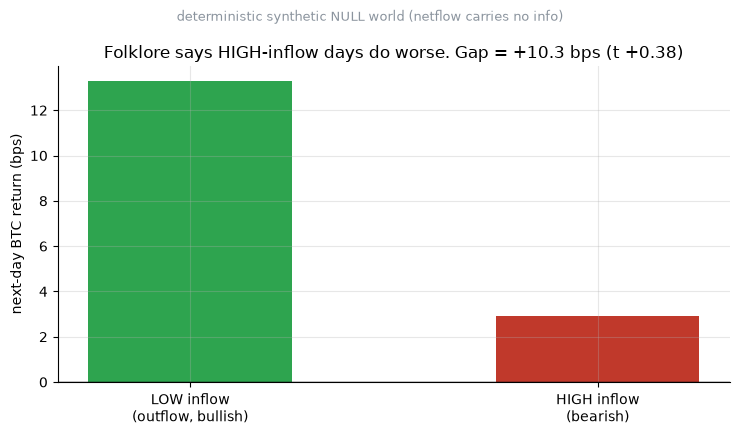

low-inflow +13.3 bps | high-inflow +2.9 bps | spread +10.3 bps | t +0.38


In [2]:
ss = st.sort_spread(NULL, lag=1, frac=0.2)
low, high = ss['low_inflow_mean']*1e4, ss['high_inflow_mean']*1e4
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['LOW inflow\n(outflow, bullish)','HIGH inflow\n(bearish)'], [low, high],
       color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next-day BTC return (bps)')
ax.set_title(f'Folklore says HIGH-inflow days do worse. Gap = {ss["spread"]*1e4:+.1f} bps (t {ss["t"]:+.2f})')
fig.suptitle('deterministic synthetic NULL world (netflow carries no info)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'low-inflow {low:+.1f} bps | high-inflow {high:+.1f} bps | spread {ss["spread"]*1e4:+.1f} bps | t {ss["t"]:+.2f}')

The gap is a statistically empty **+10.3 bps** (*t* 0.38). In a world where netflow genuinely tells you nothing, our test correctly finds nothing — no fake signal. Good: the machinery isn't inventing edges.

**Is that just one lucky shuffle? A coin-flip (placebo) test:** shuffle the netflow labels against the returns thousands of times and see how often you'd get a gap this big by pure chance.

In [3]:
p = st.placebo_pvalue(NULL, lag=1, frac=0.2, n_perm=2000, seed=584)
print(f'placebo p-value = {p:.3f}  (a real signal sits near 0; noise sits mid-range)')

placebo p-value = 0.723  (a real signal sits near 0; noise sits mid-range)


*p* = **0.72** — smack in the middle. Nothing distinguishes the real netflow ordering from a random one. Exactly what an honest engine prints when there is no effect.

## 5 · The verdict

- **Signal — None.** There's no real netflow tape to test (it's a paid product), and a fair simulation of the null shows the engine finding nothing (*t* +0.47, placebo *p* 0.72). A synthetic-only study can't earn `REAL`.
- **Tradability — Mirage.** You can't buy the data; even the *simulated* trade loses after fees.
- **Would the engine catch it if it were real? — Yes.** Plant the folklore and the test banks it (next beat). The gap is *data*, not *code*.

## 6 · Could you actually trade it?

Two walls. **First**, you can't get the netflow series without paying an on-chain data vendor — the whole thing rests on their private address labels. **Second**, even in the simulated null world, timing a long/short BTC book off the netflow sign *loses* money: about **-6.4 bps per period** after a realistic per-trade cost and a short-borrow charge (mean net Sharpe across 25 simulated worlds ≈ **-0.32**). Turnover eats you alive for nothing.

## 7 · Going further 🚪

- **Is the test any good?** The quant notebook plants a *real* bearish-netflow effect and shows the engine catches it cleanly (slope-*t* down past −2) — proof the empty result is about missing data, not a blind detector. See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
- **The crypto claims we *can* test.** [133 Crypto-Seasonality](../../133-crypto-seasonality/), [210 Crypto-Trend](../../210-crypto-trend/), [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/) run on the price/sentiment tape a free stack reaches.

*Have a real, licensed exchange-netflow tape? Fork this, drop it into `data.py`'s schema, and show the slope of forward BTC return on netflow clearing t = −2 the bearish way.*